# Análisis exploratorio del dataset (EDA)

## Librerias a usar

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
import random
import cv2
import os
from ydata_profiling import ProfileReport
from sklearn.preprocessing import MultiLabelBinarizer

## Para la data tabular de 'sample_labels.csv'

### Carga de datos

In [3]:
data_label_init = pd.read_csv(r"..\Datasets\4\sample_labels.csv")

In [4]:
data_label_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5606 entries, 0 to 5605
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5606 non-null   object 
 1   Finding Labels               5606 non-null   object 
 2   Follow-up #                  5606 non-null   int64  
 3   Patient ID                   5606 non-null   int64  
 4   Patient Age                  5606 non-null   object 
 5   Patient Gender               5606 non-null   object 
 6   View Position                5606 non-null   object 
 7   OriginalImageWidth           5606 non-null   int64  
 8   OriginalImageHeight          5606 non-null   int64  
 9   OriginalImagePixelSpacing_x  5606 non-null   float64
 10  OriginalImagePixelSpacing_y  5606 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 481.9+ KB


In [5]:
data_label_init.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


### Limpieza/corrección del campo "Patient Age"

In [6]:
data_label_init['Patient Age'].unique()

array(['060Y', '057Y', '077Y', '079Y', '055Y', '068Y', '071Y', '063Y',
       '067Y', '056Y', '058Y', '075Y', '073Y', '054Y', '078Y', '047Y',
       '050Y', '045Y', '084Y', '030Y', '049Y', '061Y', '069Y', '051Y',
       '044Y', '087Y', '059Y', '031Y', '064Y', '053Y', '082Y', '072Y',
       '046Y', '080Y', '048Y', '021Y', '038Y', '062Y', '052Y', '023Y',
       '037Y', '022Y', '032Y', '070Y', '065Y', '040Y', '042Y', '041Y',
       '028Y', '035Y', '034Y', '066Y', '019Y', '039Y', '074Y', '026Y',
       '024Y', '085Y', '016Y', '029Y', '033Y', '013Y', '017Y', '020Y',
       '014Y', '043Y', '012Y', '009Y', '011Y', '027Y', '036Y', '081Y',
       '025Y', '018Y', '076Y', '083Y', '008Y', '006Y', '015Y', '002Y',
       '005Y', '010Y', '003Y', '089Y', '007Y', '086Y', '004Y', '094Y',
       '013M', '411Y', '001D', '088Y'], dtype=object)

In [7]:
# Extrae el número
data_label_init["Patient Age Numeric"] = data_label_init["Patient Age"].str.extract('(\d+)').astype(float)

# Normaliza a años según el sufijo (Y, M, D)
data_label_init["Patient Age Clean"] = np.select(
    [
        data_label_init["Patient Age"].str.endswith("M"),
        data_label_init["Patient Age"].str.endswith("D"),
    ],
    [
        data_label_init["Patient Age Numeric"] / 12,
        data_label_init["Patient Age Numeric"] / 365,
    ],
    default=data_label_init["Patient Age Numeric"]
)

# Convierte a entero
data_label_init["Patient Age"] = data_label_init["Patient Age Clean"].round(0).astype("int64")

# Elimina columnas auxiliares
data_label_init.drop(columns=["Patient Age Numeric", "Patient Age Clean"], inplace=True)


In [8]:
data_label_init['Patient Age'].describe()

count    5606.000000
mean       46.767749
std        17.412801
min         0.000000
25%        35.000000
50%        49.000000
75%        59.000000
max       411.000000
Name: Patient Age, dtype: float64

Text(0.5, 1.0, 'Boxplot de Edad de Pacientes')

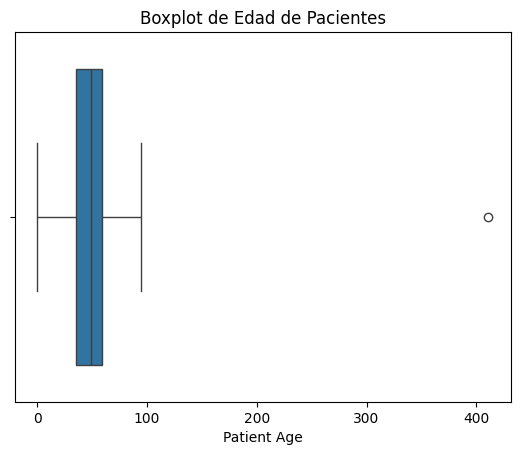

In [9]:
# Revisa valores atípicos
sns.boxplot(x=data_label_init['Patient Age'])
plt.title('Boxplot de Edad de Pacientes')


In [10]:
# Conversion del unico valor atipico 411 a 41
data_label_init.loc[data_label_init['Patient Age'] == 411, 'Patient Age'] = 41


### Limpieza/corrección del campo "Finding Labels"

In [11]:
# Separa etiquetas múltiples
data_label_init["Finding Labels"] = data_label_init["Finding Labels"].str.split('|')

# Crea columnas binarias
mlb = MultiLabelBinarizer()
labels_df = pd.DataFrame(mlb.fit_transform(data_label_init["Finding Labels"]),
                         columns=mlb.classes_,
                         index=data_label_init.index)
data_label_init = pd.concat([data_label_init, labels_df], axis=1)


### Reporte EDA con "ydata_profiling"

In [12]:
report_ydp = ProfileReport(data_label_init, explorative=True)
report_ydp.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 133.36it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Para la data de imagenes

In [13]:
images_path = "../Datasets/4/sample/images"

### Muestra visual aleatoria

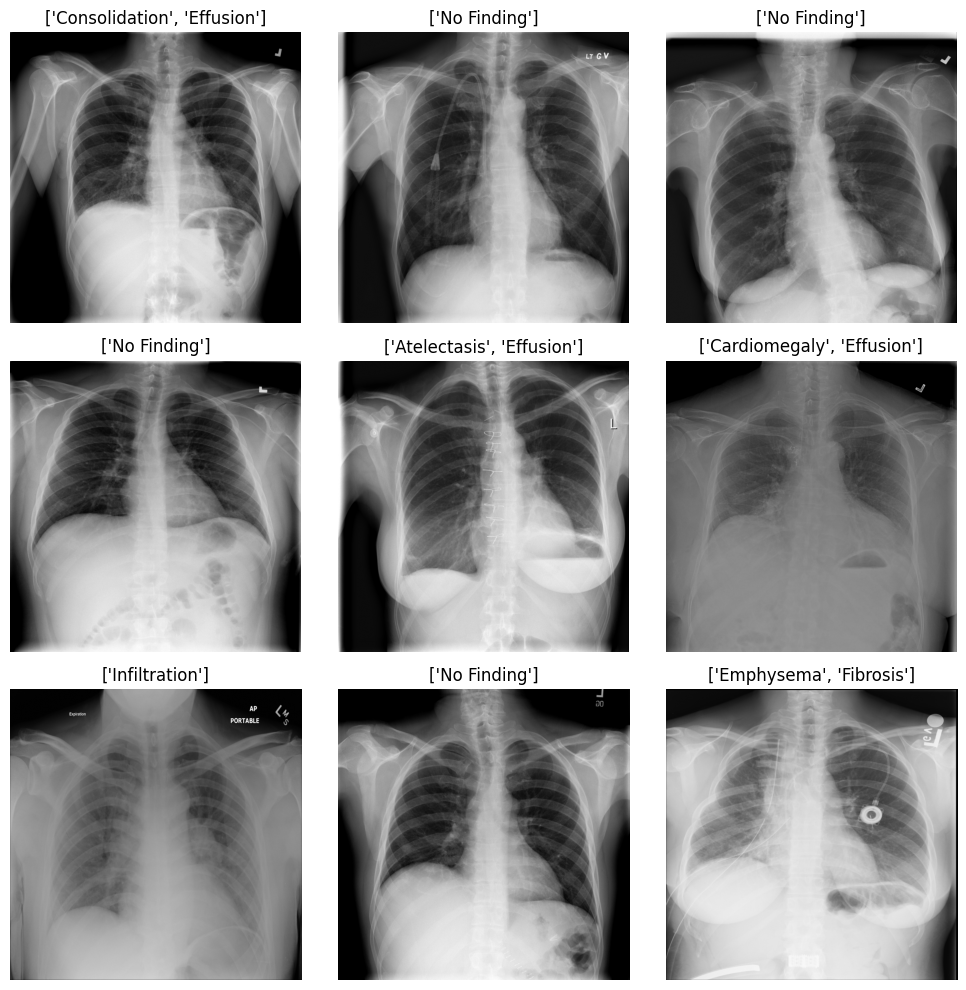

In [17]:
def mostrar_muestras(n=9):
    plt.figure(figsize=(10,10))
    subset = data_label_init.sample(n)
    for i, row in enumerate(subset.itertuples(), 1):
        path = os.path.join(images_path, row._1)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(3, 3, i)
        plt.imshow(img, cmap="gray")
        plt.title(str(row._2))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

mostrar_muestras(9)

### Análisis de resoluciones

Analizando resoluciones: 100%|██████████| 5606/5606 [01:03<00:00, 88.20it/s] 


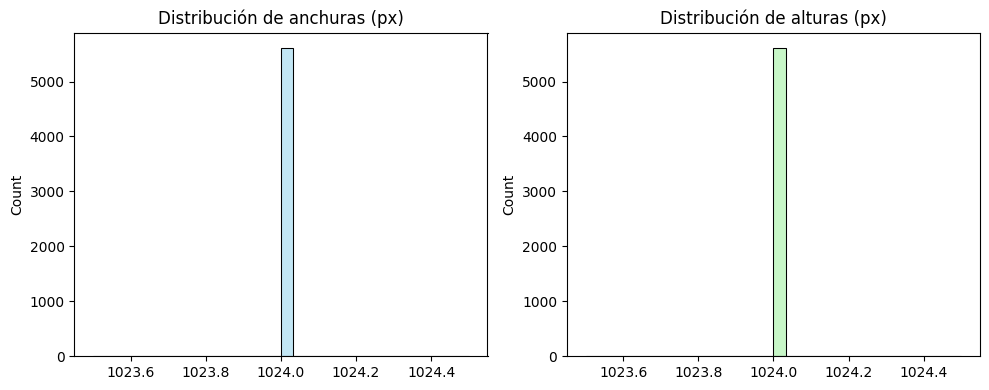

Tamaño promedio: 1024x1024 px


In [14]:
widths, heights = [], []
sample_images = data_label_init["Image Index"]
for img_name in tqdm(sample_images, desc="Analizando resoluciones"):
    path = os.path.join(images_path, img_name)
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

# Gráficas
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(widths, bins=30, kde=True, color="skyblue")
plt.title("Distribución de anchuras (px)")

plt.subplot(1, 2, 2)
sns.histplot(heights, bins=30, kde=True, color="lightgreen")
plt.title("Distribución de alturas (px)")
plt.tight_layout()
plt.show()

print(f"Tamaño promedio: {np.mean(widths):.0f}x{np.mean(heights):.0f} px")

### Verificación del tipo de canal

In [ ]:
channel_types = []
for img_name in tqdm(sample_images, desc="Verificando tipo de canal"):
    path = os.path.join(images_path, img_name)
    img = cv2.imread(path)
    if img is not None:
        if len(img.shape) == 2:
            channel_types.append("Grayscale")
        elif len(img.shape) == 3:
            channel_types.append("RGB")
        else:
            channel_types.append("Otro")
    else:
        channel_types.append("No leída")

# Resumen
print(Counter(channel_types))

Verificando tipo de canal: 100%|██████████| 5606/5606 [00:58<00:00, 96.46it/s] 

Counter({'RGB': 5606})


### Histograma de intensidad

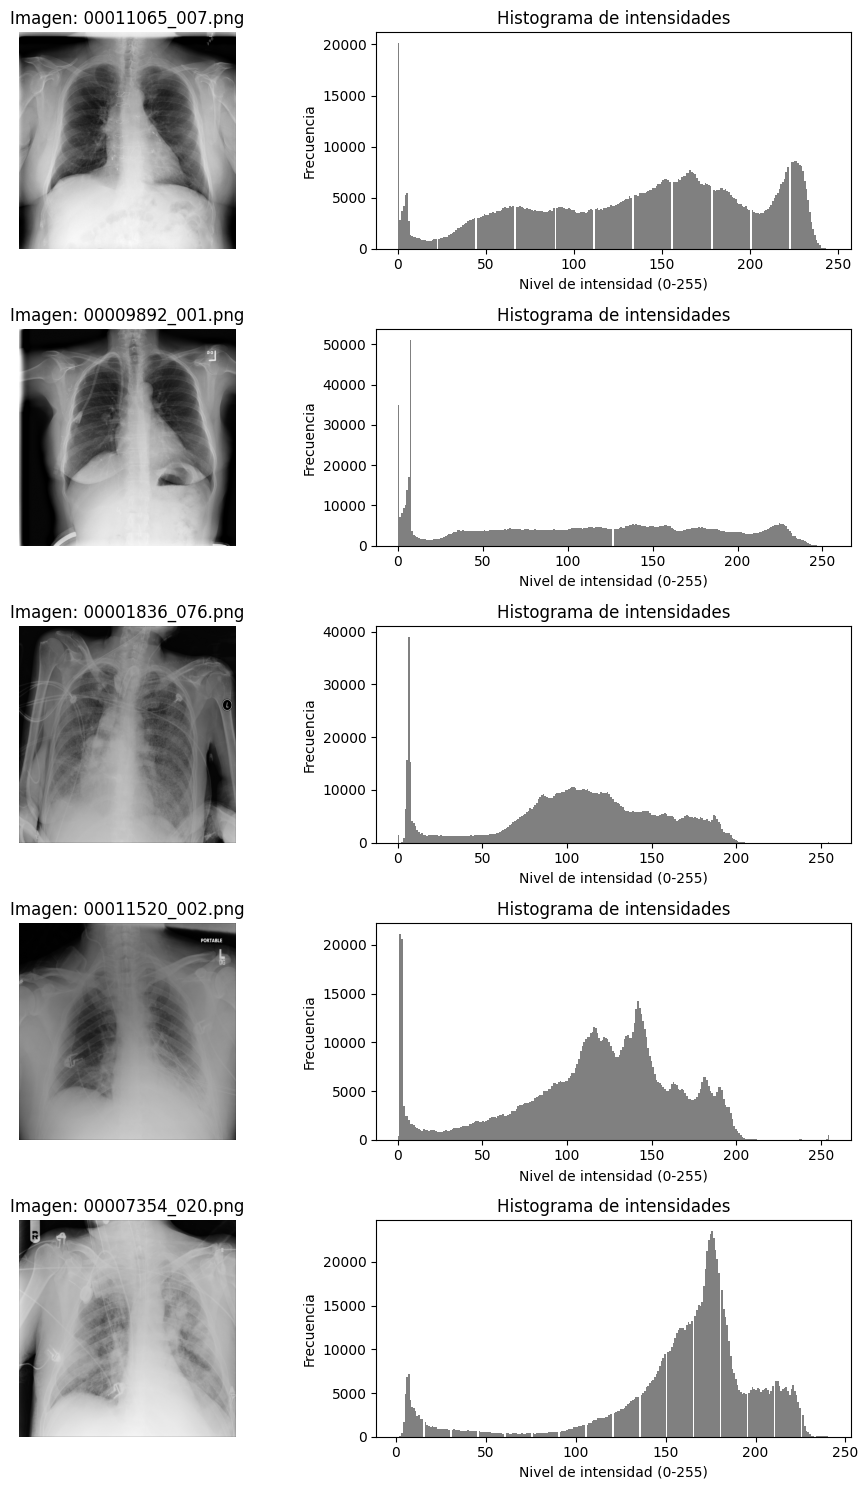

In [20]:
n = 5
subset = data_label_init.sample(n, random_state=42)

plt.figure(figsize=(10, 3 * n))

for i, row in enumerate(subset.itertuples(), 1):
    path = os.path.join(images_path, row._1)
    gray_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    # Imagen
    plt.subplot(n, 2, 2*i - 1)
    plt.imshow(gray_img, cmap='gray')
    plt.title(f"Imagen: {row._1}")
    plt.axis("off")
    
    # Histograma
    plt.subplot(n, 2, 2*i)
    plt.hist(gray_img.ravel(), bins=256, color='gray')
    plt.title("Histograma de intensidades")
    plt.xlabel("Nivel de intensidad (0-255)")
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Exportación de dataset para la modelación

In [ ]:
output_dir = r"..\Datasets\4"
os.makedirs(output_dir, exist_ok=True)

output_file = f"{output_dir}/sample_labels_processed.csv"

data_label_init.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Archivo exportado correctamente: {output_file}")

Archivo exportado correctamente: ..\Datasets\4/sample_labels_processed.csv
